In [1]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader, TensorDataset, Subset

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from tensorflow.keras.preprocessing.sequence import pad_sequences

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

/home/qfu1/.local/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-04-01 19:46:11.962428: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-01 19:46:11.980524: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743561972.003564 2931088 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0

In [2]:
with open("/home/qfu1/ML_crystring/ML_crystring/CleanData/token_to_number_combined.json", "r") as f:
    token_to_number_combined = json.load(f)
with open("/home/qfu1/ML_crystring/ML_crystring/CleanData/number_to_token_combined.json", "r") as f:
    number_to_token_combined = json.load(f)

In [3]:
df = pd.read_json("/home/qfu1/ML_crystring/ML_crystring/CleanData/CleanData(Tokenized).json", orient="records")
df.head()

,string,band_gap,energy_above_hull,tokens,tokenized
0,P 4bar n 2 Tb 4f 0.355 0.000 0.000,0.0,0.0,"[START, P, 4bar, n, 2, Tb, 4f, 3, 5, 5, 0, 0, ...","[13, 15, 101, 81, 47, 107, 58, 2, 8, 8, 1, 1, ..."
1,P 6bar 1 1 Eu 2g 0.000 0.000 0.545 C 2g 0.000 ...,0.0,0.0,"[START, P, 6bar, 1, 1, Eu, 2g, 0, 0, 0, 0, 0, ...","[13, 15, 89, 17, 17, 145, 152, 1, 1, 1, 1, 1, ..."
2,I 4bar c 2 Tl 4a 0.000 0.000 0.000 Cl 8f 0.000...,0.0,0.0,"[START, I, 4bar, c, 2, Tl, 4a, 0, 0, 0, 0, 0, ...","[13, 34, 101, 24, 47, 122, 27, 1, 1, 1, 1, 1, ..."
3,P m c 21 Kr 4c 0.595 0.217 0.468 Tb 2a 0.000 0...,0.0,0.0,"[START, P, m, c, 21, Kr, 4c, 5, 9, 5, 2, 1, 7,...","[13, 15, 11, 24, 104, 277, 33, 8, 10, 8, 6, 3,..."
4,P 3bar 1 c Co 2c 0.000 0.000 0.000,0.0,0.0,"[START, P, 3bar, 1, c, Co, 2c, 0, 0, 0, 0, 0, ...","[13, 15, 20, 17, 24, 72, 52, 1, 1, 1, 1, 1, 1,..."


In [4]:
max_sequence_len = max([len(seq) for seq in df['tokenized']])
X = np.array(pad_sequences(df['tokenized'], maxlen=max_sequence_len, padding="pre"))
y = np.array(df["energy_above_hull"]).reshape(-1,1)

# scaler = StandardScaler()
# y = scaler.fit_transform(y)
# eps = 1e-3
# y = np.log(y + eps)

test_X = torch.tensor(X[:30], dtype=torch.long)
test_y = torch.tensor(y[:30], dtype=torch.float)

remaining_X = torch.tensor(X[30:], dtype=torch.long)
remaining_Y = torch.tensor(y[30:], dtype=torch.float)

print(test_X.shape, remaining_X.shape)
print(test_y.shape, remaining_Y.shape)

torch.Size([30, 639]) torch.Size([19059, 639])
torch.Size([30, 1]) torch.Size([19059, 1])


In [71]:
vocab_size = len(token_to_number_combined)+1
emb_dim = 32
hidden_size = 64
batch_size=512

In [72]:
X_trainval, X_test, y_trainval, y_test = train_test_split(remaining_X, remaining_Y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [85]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=3):
        super(LSTMModel, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        self.lstm_layer = nn.LSTM(input_size=emb_dim, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 512),  
            nn.SiLU(),
            nn.Linear(512, 256),
            nn.SiLU(),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        # torch.Size([batch_size, max_sequence_len])
        embedding = self.embedding_layer(x)
        rnn_output, (hidden_state, cell_state) = self.lstm_layer(embedding)
        last_output = rnn_output[:, -1, :]
        # torch.Size([batch_size, hidden_size])
        final_output = self.fc(last_output)
        # torch.Size([batch_size, 1])
        return final_output

In [86]:
def trian(train_loader, val_loader, model, criterion, optimizer, epochs, mute=False):
    TrainLoss = []
    ValLoss = []
    model.to(device)
    start_time = time.time()
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()                
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
    
        # Validation phase
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                val_loss += loss.item()

        train_loss = train_loss/len(train_loader)
        val_loss = val_loss/len(val_loader)
        
        TrainLoss.append(train_loss)
        ValLoss.append(val_loss)
        
        if not mute:
            if (epoch + 1) % 10 == 0:
                end_time = time.time()
                training_time = end_time - start_time
                print(f'Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {loss:.4f}, Time: {training_time:.2f}')
            
    return model, TrainLoss, ValLoss

In [92]:
lr=5e-3
wd=5e-5
epochs = 200
num_layers = 3

model = LSTMModel(vocab_size=vocab_size, emb_dim=emb_dim, hidden_size=hidden_size, num_layers=num_layers)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=lr,weight_decay=wd)
model, TrainLoss, ValLoss = trian(train_loader, val_loader, model, criterion, optimizer, epochs)

Epoch [10/200] - Train Loss: 0.3648, Val Loss: 0.5044, Time: 5.45
Epoch [20/200] - Train Loss: 0.2893, Val Loss: 0.1863, Time: 10.74
Epoch [30/200] - Train Loss: 0.1802, Val Loss: 0.0747, Time: 15.99
Epoch [40/200] - Train Loss: 0.1287, Val Loss: 0.1176, Time: 21.21
Epoch [50/200] - Train Loss: 0.1089, Val Loss: 0.2041, Time: 26.45
Epoch [60/200] - Train Loss: 0.0922, Val Loss: 0.0924, Time: 31.77
Epoch [70/200] - Train Loss: 0.0675, Val Loss: 0.0533, Time: 37.02
Epoch [80/200] - Train Loss: 0.0499, Val Loss: 0.0488, Time: 42.34
Epoch [90/200] - Train Loss: 0.0387, Val Loss: 0.0413, Time: 47.58
Epoch [100/200] - Train Loss: 0.0333, Val Loss: 0.0219, Time: 52.82
Epoch [110/200] - Train Loss: 0.0298, Val Loss: 0.0167, Time: 58.08
Epoch [120/200] - Train Loss: 0.0212, Val Loss: 0.0143, Time: 63.33
Epoch [130/200] - Train Loss: 0.0236, Val Loss: 0.0167, Time: 68.57
Epoch [140/200] - Train Loss: 0.0183, Val Loss: 0.0121, Time: 73.83
Epoch [150/200] - Train Loss: 0.0154, Val Loss: 0.0128, Ti

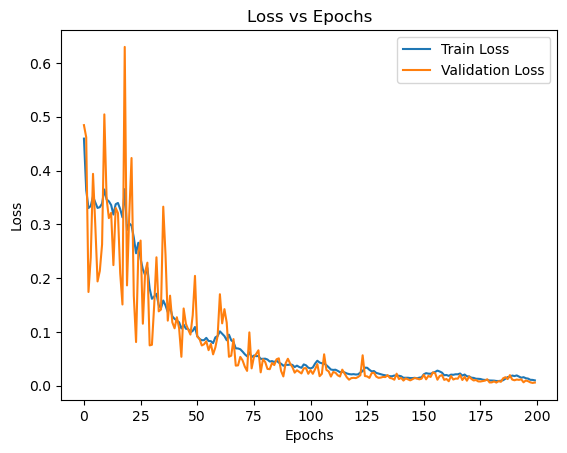

In [93]:
plt.plot(TrainLoss, label='Train Loss')
plt.plot(ValLoss, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

In [94]:
model.eval()
with torch.no_grad():
    X_test = X_test.to(device)
    all_predictions = model(X_test).cpu()
    # all_predictions = scaler.inverse_transform(all_predictions)

model.eval()
all_predictions_train = []
with torch.no_grad():
    for X_val, y_val in train_loader:
        X_val = X_val.to(device)
        pred = model(X_val).cpu()
        # all_predictions_train.append(torch.tensor(scaler.inverse_transform(pred)))
        all_predictions_train.append(pred)
        
all_predictions_train = torch.cat(all_predictions_train, dim=0)

In [95]:
# y_train_original = scaler.inverse_transform(y_train)
# y_test_original = scaler.inverse_transform(y_test)

y_train_original = y_train
y_test_original = y_test

Test Score:
Mean Squared Error (MSE): 0.3130
Mean Absolute Error (MAE): 0.3024
R² Score: 0.0948
Train Score:
Mean Squared Error (MSE): 0.6642
Mean Absolute Error (MAE): 0.4481
R² Score: -0.9172


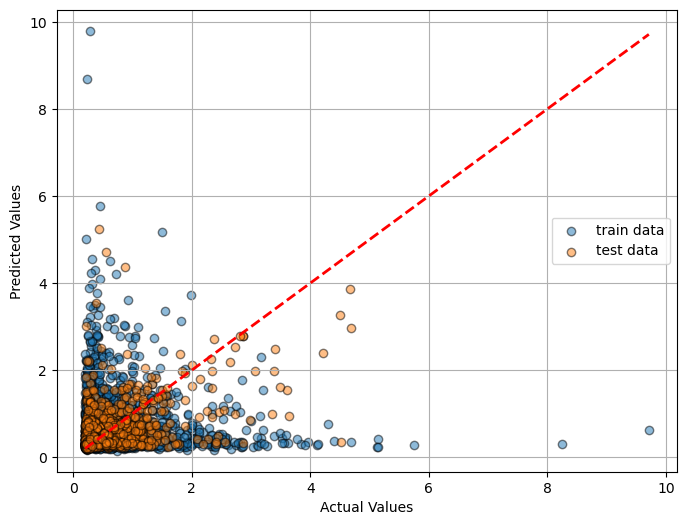

In [96]:
mse = mean_squared_error(y_test_original, all_predictions)
mae = mean_absolute_error(y_test_original, all_predictions)
r2 = r2_score(y_test_original, all_predictions)

print("Test Score:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

mse = mean_squared_error(y_train_original, all_predictions_train)
mae = mean_absolute_error(y_train_original, all_predictions_train)
r2 = r2_score(y_train_original, all_predictions_train)

print("Train Score:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_train_original, all_predictions_train, alpha=0.5, edgecolors='k', label='train data')
plt.scatter(y_test_original, all_predictions, alpha=0.5, edgecolors='k', label='test data')
plt.plot([min(y_train_original), max(y_train_original)], [min(y_train_original), max(y_train_original)], color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid()
plt.legend()
plt.show()